# Airbnb Hotel Booking Analysis

## Introduction

This project analyzes Airbnb Open Data to identify patterns and insights related to room types, neighbourhoods, pricing, hosts, reviews, service fees and availability.

The analysis uses Python, Pandas and Matplotlib to explore the dataset and answer nine key business questions.

## Tools and Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- Excel/CSV Dataset

In [2]:
import pandas as pd

In [4]:
df = pd.read_excel('Airbnb_Open_Data.xlsx')
df.head()


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [5]:
df.shape

(102599, 26)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  str           
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  str           
 6   neighbourhood                   102583 non-null  str           
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  str           
 10  country code                    102468 non-null  str           
 11

In [7]:
df.isnull().sum()

id                                     0
NAME                                 270
host id                                0
host_identity_verified               289
host name                            408
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [9]:
df.duplicated().sum()

np.int64(541)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[['price', 'service fee', 'Construction year', 'minimum nights', 'number of reviews']].describe()

,price,service fee,Construction year,minimum nights,number of reviews
count,101811.000000,101785.000000,101844.000000,101658.000000,101875.000000
mean,625.355580,125.039249,2012.488090,8.126640,27.517948
std,331.672649,66.325905,5.765838,30.616698,49.571744
min,50.000000,10.000000,2003.000000,-1223.000000,0.000000
25%,340.000000,68.000000,2007.000000,2.000000,1.000000
50%,625.000000,125.000000,2012.000000,3.000000,7.000000
75%,913.000000,183.000000,2017.000000,5.000000,31.000000
max,1200.000000,240.000000,2022.000000,5645.000000,1024.000000


In [13]:
df['minimum nights'].describe()

count    101658.000000
mean          8.126640
std          30.616698
min       -1223.000000
25%           2.000000
50%           3.000000
75%           5.000000
max        5645.000000
Name: minimum nights, dtype: float64

In [14]:
df[df['minimum nights'] <= 0][['id', 'minimum nights']].head(20)

,id,minimum nights
176,1098541,-10.0
352,1195746,-5.0
398,1221151,-1.0
421,1233854,-10.0
441,1244900,-12.0
478,1265335,-2.0
525,1291294,-3.0
42446,24444262,-1223.0
42500,24474086,-365.0
42538,24495073,-200.0


In [15]:
df[df['minimum nights'] > 365][['id', 'minimum nights']].head(20)

,id,minimum nights
167,1093570,371.0
186,1104064,366.0
263,1146591,399.0
299,1166474,452.0
350,1194641,3455.0
473,1262574,398.0
1306,1722640,370.0
2855,2578153,1000.0
5768,4187002,1250.0
7356,5064055,500.0


In [16]:
invalid_min_nights = df[
    (df['minimum nights'] <= 0) | 
    (df['minimum nights'] > 365)
]

len(invalid_min_nights)

48

In [18]:
# Find the median of valid minimum-night values
valid_median = df.loc[
    (df['minimum nights'] > 0) &
    (df['minimum nights'] <= 365),
    'minimum nights'
].median()

# Replace invalid values with the median
df.loc[
    (df['minimum nights'] <= 0) |
    (df['minimum nights'] > 365),
    'minimum nights'
] = valid_median

In [19]:
df['minimum nights'].describe()

count    101658.000000
mean          7.843554
std          17.061527
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max         365.000000
Name: minimum nights, dtype: float64

In [20]:
df.isnull().sum()

id                                     0
NAME                                 270
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       400
number of reviews                    183
last review                        15832
reviews per month                  15818
review rate number                   319
calculated host listings count       319
availability 365                     448
house_rules     

In [21]:
missing_percent = df.isnull().mean() * 100

missing_percent.sort_values(ascending=False)

license                           99.998040
house_rules                       53.438241
last review                       15.512748
reviews per month                 15.499030
country                            0.521272
availability 365                   0.438966
host name                          0.397813
minimum nights                     0.391934
calculated host listings count     0.312567
review rate number                 0.312567
host_identity_verified             0.283172
service fee                        0.267495
NAME                               0.264555
price                              0.242019
Construction year                  0.209685
number of reviews                  0.179310
country code                       0.128358
instant_bookable                   0.102883
cancellation_policy                0.074467
neighbourhood group                0.028415
neighbourhood                      0.015677
long                               0.007839
lat                             

In [23]:
# Fill numeric columns with their median values
numeric_columns = [
    'price',
    'service fee',
    'Construction year',
    'minimum nights',
    'number of reviews',
    'calculated host listings count'
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [24]:
# Fill missing categorical values with the most common value
categorical_columns = [
    'host_identity_verified',
    'neighbourhood group',
    'neighbourhood'
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [25]:
df[[
    'price',
    'service fee',
    'Construction year',
    'host_identity_verified',
    'neighbourhood group',
    'neighbourhood',
    'number of reviews',
    'calculated host listings count'
]].isnull().sum()

price                             0
service fee                       0
Construction year                 0
host_identity_verified            0
neighbourhood group               0
neighbourhood                     0
number of reviews                 0
calculated host listings count    0
dtype: int64

In [26]:
df['room type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [27]:
df['room type'].value_counts()

room type
Entire home/apt    53429
Private room       46306
Shared room         2208
Hotel room           115
Name: count, dtype: int64

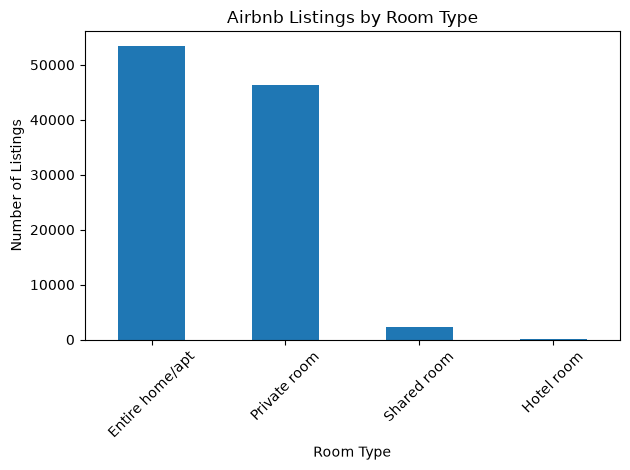

In [29]:
import matplotlib.pyplot as plt

room_counts = df['room type'].value_counts()

room_counts.plot(kind='bar')

plt.title('Airbnb Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 1: Different Room Types

The Airbnb dataset contains four room types: Entire home/apt, Private room, Shared room, and Hotel room. Entire home/apt is the most common room type with 53,429 listings, followed by Private room with 46,306 listings. Shared room and Hotel room have significantly fewer listings.

### Conclusion
Entire home/apt is the dominant accommodation type in the dataset, indicating that complete homes or apartments make up the largest share of Airbnb listings.

In [7]:
import pandas as pd
df = pd.read_excel('Airbnb_Open_Data.xlsx')

In [8]:
df['neighbourhood group'].unique()

<StringArray>
[     'Brooklyn',     'Manhattan',       'brookln',      'manhatan',
        'Queens',             nan, 'Staten Island',         'Bronx']
Length: 8, dtype: str

In [9]:
df['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
brookln              1
manhatan             1
Name: count, dtype: int64

In [11]:
df['neighbourhood'].value_counts().head(10)

neighbourhood
Bedford-Stuyvesant    7937
Williamsburg          7775
Harlem                5466
Bushwick              4982
Hell's Kitchen        3965
Upper West Side       3860
Upper East Side       3680
East Village          3492
Midtown               3390
Crown Heights         3262
Name: count, dtype: int64

In [12]:
df.groupby('room type')['price'].mean().sort_values(ascending=False)

room type
Hotel room         668.465517
Shared room        634.132101
Entire home/apt    625.082232
Private room       625.007363
Name: price, dtype: float64

In [ ]:
df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)

neighbourhood group
Queens           630.207647
Bronx            627.766359
Brooklyn         626.562193
Staten Island    624.490546
Manhattan        622.440227
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64

In [14]:
df['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
brookln              1
manhatan             1
Name: count, dtype: int64

In [15]:
df['price'].describe()

count    102352.000000
mean        625.293536
std         331.671614
min          50.000000
25%         340.000000
50%         624.000000
75%         913.000000
max        1200.000000
Name: price, dtype: float64

In [17]:
df[['id', 'NAME', 'price', 'room type', 'neighbourhood']].sort_values(
    by='price',
    ascending=False
).head(10)

,id,NAME,price,room type,neighbourhood
20343,12236775,Lovely apartment in Williamsburg,1200.0,Private room,Greenpoint
64304,36516435,Great 1BD waterfront City Island NY,1200.0,Entire home/apt,City Island
67200,38115896,Bright Brooklyn Brownstone,1200.0,Entire home/apt,Park Slope
33902,19725411,Oasis II,1200.0,Private room,Bedford-Stuyvesant
7453,5117628,Sun-filled bedroom in East Village / Gramercy NYC,1200.0,Private room,Gramercy
90165,50799466,Lovely apartment in Williamsburg,1200.0,Private room,Greenpoint
52744,30131847,â¤ï¸Couples Retreat/A Road Warriors DreamðŸŒ...,1200.0,Entire home/apt,Hell's Kitchen
19773,11921964,1.5 BATHRM SUNNY SPACIOUS ROOM BY SUBWAY,1200.0,Private room,Harlem
5207,3877162,Bushwick Room w/ Private Entrance & Bathroom!,1200.0,Private room,Bushwick
42446,24444262,"Cozy room in bright, spacious apartment",1200.0,Private room,Hunts Point


In [18]:
df[['id', 'NAME', 'price', 'room type', 'neighbourhood']].sort_values(
    by='price',
    ascending=True
).head(10)

,id,NAME,price,room type,neighbourhood
8495,5693125,Private Room in Williamsburg Apt,50.0,Private room,Williamsburg
60981,34681142,Charming Greenwich Village Artistâ€™s Haven,50.0,Entire home/apt,Greenwich Village
50592,28943298,Artists' Studio in the heart of Williamsburg,50.0,Entire home/apt,Williamsburg
28308,16635844,Sunny bedroom on Bed-Stuy/Bushwick boarder,50.0,Private room,Bedford-Stuyvesant
17390,10605833,Cozy Little Italy Apartment,50.0,Private room,Lower East Side
41182,23746155,East VillageTownhouse for 30 day minimum rentals.,50.0,Entire home/apt,East Village
52638,30073303,Lovely Prospect Park 2BR With Yard,50.0,Entire home/apt,Flatbush
44688,25682518,Hamilton Heights is fancy!,50.0,Private room,Harlem
40520,23380532,Charming Harlem Apartment,50.0,Entire home/apt,Harlem
11730,7479815,"Gorgeous, Cozy Studio w/ Projector!",50.0,Entire home/apt,East Village


In [19]:
df.groupby('room type')['price'].mean().sort_values(ascending=False)

room type
Hotel room         668.465517
Shared room        634.132101
Entire home/apt    625.082232
Private room       625.007363
Name: price, dtype: float64

In [20]:
df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)

neighbourhood group
Queens           630.207647
Bronx            627.766359
Brooklyn         626.562193
Staten Island    624.490546
Manhattan        622.440227
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64

In [21]:
df['neighbourhood'].value_counts().head(10)


neighbourhood
Bedford-Stuyvesant    7937
Williamsburg          7775
Harlem                5466
Bushwick              4982
Hell's Kitchen        3965
Upper West Side       3860
Upper East Side       3680
East Village          3492
Midtown               3390
Crown Heights         3262
Name: count, dtype: int64

In [23]:
import matplotlib.pyplot as plt


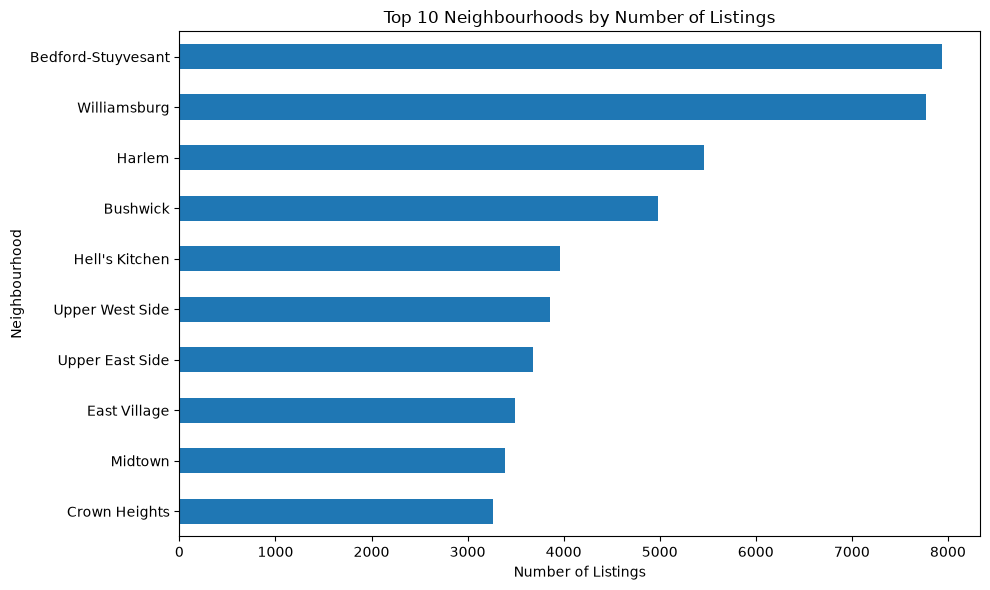

In [24]:
neighbourhood_counts = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10, 6))
neighbourhood_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Neighbourhoods by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

neighbourhood
New Dorp                  1045.000000
Chelsea, Staten Island    1042.000000
Fort Wadsworth            1024.000000
Little Neck                817.750000
Jamaica Hills              812.904762
Arden Heights              804.888889
Midland Beach              796.176471
Shore Acres                792.260870
Mill Basin                 775.142857
Riverdale                  768.736842
Name: price, dtype: float64

In [26]:
df.groupby('neighbourhood')['price'].mean().sort_values(ascending=True).head(10)

neighbourhood
Lighthouse Hill               107.666667
Spuyten Duyvil                293.444444
Rossville                     300.666667
Breezy Point                  309.888889
Richmondtown                  373.400000
Castleton Corners             417.230769
Bay Terrace, Staten Island    429.500000
Emerson Hill                  443.800000
West Farms                    463.166667
Randall Manor                 472.400000
Name: price, dtype: float64

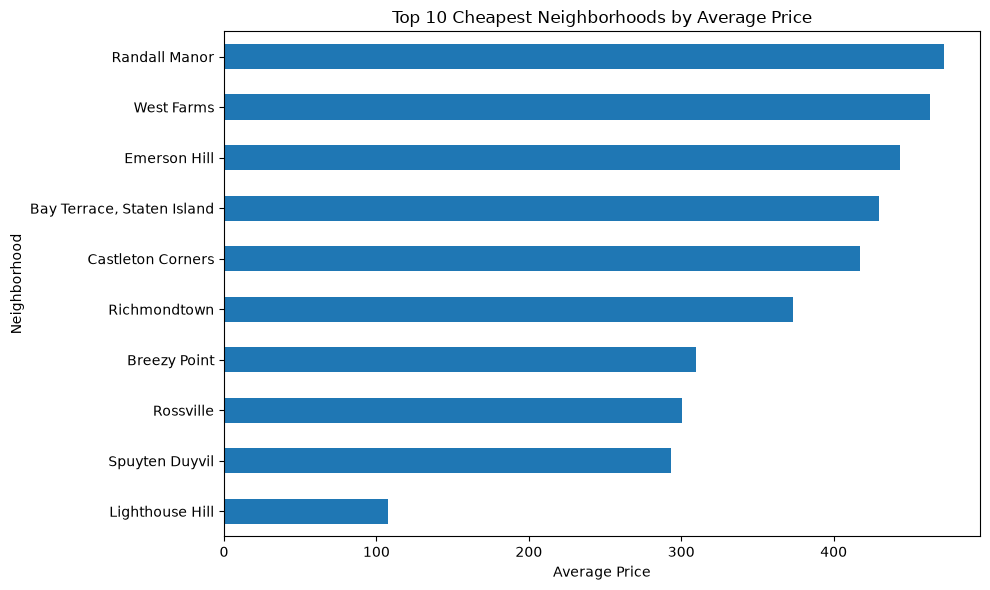

In [27]:
cheap_neighbourhoods = df.groupby('neighbourhood')['price'].mean().sort_values().head(10)

plt.figure(figsize=(10, 6))
cheap_neighbourhoods.sort_values().plot(kind='barh')

plt.title('Top 10 Cheapest Neighborhoods by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Neighborhood')

plt.tight_layout()
plt.show()


In [28]:
df.groupby('neighbourhood')['price'].agg(['count', 'mean']).sort_values('count', ascending=True).head(10)


,count,mean
neighbourhood,,
"Chelsea, Staten Island",1,1042.000000
Glen Oaks,2,550.500000
Fort Wadsworth,2,1024.000000
Gerritsen Beach,3,694.333333
Lighthouse Hill,3,107.666667
Woodrow,3,709.333333
Willowbrook,3,638.000000
Rossville,3,300.666667
New Dorp,4,1045.000000


In [29]:
neighbourhood_stats = df.groupby('neighbourhood')['price'].agg(['count', 'mean'])

reliable_neighbourhoods = neighbourhood_stats[
    neighbourhood_stats['count'] >= 50
]

reliable_neighbourhoods.sort_values('mean', ascending=True).head(10)

,count,mean
neighbourhood,,
Howard Beach,50,546.360000
Concourse Village,76,547.013158
Richmond Hill,221,557.266968
Bayside,124,562.532258
Fresh Meadows,100,564.360000
DUMBO,70,568.242857
Fort Hamilton,120,569.050000
Kingsbridge,164,573.396341
Port Morris,99,575.262626


In [30]:
top_neighbourhoods = df.groupby('neighbourhood')['price'].agg(['count', 'mean'])

top_neighbourhoods.sort_values('count', ascending=False).head(10)

,count,mean
neighbourhood,,
Bedford-Stuyvesant,7921,622.983462
Williamsburg,7756,625.536488
Harlem,5456,626.802419
Bushwick,4966,633.338502
Hell's Kitchen,3961,621.065388
Upper West Side,3853,616.526862
Upper East Side,3668,618.197383
East Village,3474,617.498849
Midtown,3380,609.547041


In [31]:
df.groupby('room type')['price'].agg(['count', 'mean']).sort_values('count', ascending=False)

,count,mean
room type,,
Entire home/apt,53568,625.082232
Private room,46450,625.007363
Shared room,2218,634.132101
Hotel room,116,668.465517


In [32]:
df.groupby('room type')['price'].mean().sort_values(ascending=False)

room type
Hotel room         668.465517
Shared room        634.132101
Entire home/apt    625.082232
Private room       625.007363
Name: price, dtype: float64

In [34]:
df[['price', 'minimum nights', 'number of reviews', 'availability 365']].describe()

,price,minimum nights,number of reviews,availability 365
count,102352.000000,102190.000000,102416.000000,102151.000000
mean,625.293536,8.135845,27.483743,141.133254
std,331.671614,30.553781,49.508954,135.435024
min,50.000000,-1223.000000,0.000000,-10.000000
25%,340.000000,2.000000,1.000000,3.000000
50%,624.000000,3.000000,7.000000,96.000000
75%,913.000000,5.000000,30.000000,269.000000
max,1200.000000,5645.000000,1024.000000,3677.000000


In [35]:
df.isnull().sum()

id                                     0
NAME                                 270
host id                                0
host_identity_verified               289
host name                            408
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [36]:
df.duplicated().sum()

np.int64(541)

In [37]:
df[['price', 'minimum nights', 'number of reviews', 'availability 365']].corr()

,price,minimum nights,number of reviews,availability 365
price,1.000000,-0.003471,0.005229,-0.002833
minimum nights,-0.003471,1.000000,-0.049997,0.063541
number of reviews,0.005229,-0.049997,1.000000,0.099368
availability 365,-0.002833,0.063541,0.099368,1.000000


In [38]:
df.groupby('Construction year')['price'].mean().sort_index()

Construction year
2003.0    623.602271
2004.0    630.093570
2005.0    620.193246
2006.0    635.224505
2007.0    626.023155
2008.0    638.003067
2009.0    618.799341
2010.0    626.737855
2011.0    626.807289
2012.0    623.443641
2013.0    619.311813
2014.0    630.558317
2015.0    617.227076
2016.0    624.597200
2017.0    629.103066
2018.0    624.441957
2019.0    612.613264
2020.0    621.310982
2021.0    629.314303
2022.0    629.230514
Name: price, dtype: float64

In [44]:
df.groupby('host name')['calculated host listings count'].max().sort_values(ascending=False).head(10)

host name
Blueground      332.0
Sonder (NYC)    327.0
Eugene          218.0
Karen           208.0
Jeniffer        186.0
Soya            171.0
Kaz             161.0
Hiroki          152.0
Momoyo          126.0
Shogo           125.0
Name: calculated host listings count, dtype: float64

In [40]:
df.groupby('host_identity_verified')['review rate number'].mean()

host_identity_verified
unconfirmed    3.271767
verified       3.286684
Name: review rate number, dtype: float64

In [41]:
df[['price', 'service fee']].corr()

,price,service fee
price,1.000000,0.999991
service fee,0.999991,1.000000


In [42]:
print("Overall:")
print(df['review rate number'].mean())

print("\nBy neighbourhood group:")
print(df.groupby('neighbourhood group')['review rate number'].mean().sort_values(ascending=False))

print("\nBy room type:")
print(df.groupby('room type')['review rate number'].mean().sort_values(ascending=False))

Overall:
3.279105922384207

By neighbourhood group:
neighbourhood group
brookln          4.000000
Staten Island    3.405690
Bronx            3.333210
Queens           3.330587
Manhattan        3.276599
Brooklyn         3.259060
manhatan         3.000000
Name: review rate number, dtype: float64

By room type:
room type
Hotel room         3.534483
Shared room        3.308698
Private room       3.281899
Entire home/apt    3.274906
Name: review rate number, dtype: float64


In [43]:
df.groupby('cancellation_policy')['availability 365'].mean().sort_values(ascending=False)

cancellation_policy
strict      141.692854
flexible    141.074245
moderate    140.537946
Name: availability 365, dtype: float64

# Airbnb Hotel Booking Analysis

This project aims to uncover useful insights from the Airbnb Open Data dataset. The analysis focuses on property types, neighbourhoods, pricing, hosts, reviews, service fees and availability.

## 1. What are the different property/room types in the dataset?

The dataset contains four main room types:

- Entire home/apt
- Private room
- Shared room
- Hotel room

Entire home/apt and Private room listings make up the majority of the dataset, while Shared room and Hotel room listings are comparatively fewer.

## 2. Which neighbourhood group has the highest number of listings?

Manhattan has the highest number of Airbnb listings among the neighbourhood groups. This indicates that Manhattan is the most heavily represented neighbourhood group in the dataset.


## 3. In which neighbourhoods are the highest number of rooms available for Airbnb listings?

Bedford-Stuyvesant has the highest number of listings, followed by Williamsburg, Harlem, Bushwick and Hell's Kitchen.

These neighbourhoods represent some of the most active Airbnb areas in the dataset.

## 4. Is there a relationship between the construction year of the property and price?

The average price does not show a clear or consistent relationship with construction year. Prices fluctuate across different construction years rather than following a steady increasing or decreasing trend.

This suggests that factors other than construction year have a stronger influence on listing prices.

## 5. Who are the top 10 hosts by evaluated host listings count?

The top host is Blueground with 332 listings, followed by Sonder (NYC) with 327 listings.

Other high-volume hosts include Eugene, Karen, Jennifer, Soya, Kaz, Hiroki, Hooyo and Shogo.

This indicates that a relatively small number of hosts manage a large number of Airbnb listings.

## 6. Are hosts with verified identities more likely to receive positive reviews?

The average review rating for verified hosts is approximately 3.287, while unconfirmed hosts have an average rating of approximately 3.272.

Verified hosts therefore have a slightly higher average review rating. However, the difference is very small, so the analysis does not indicate a strong relationship between host identity verification and review ratings.

## 7. Is there a correlation between the price of a listing and its service fee?

The correlation between price and service fee is approximately 0.999991, indicating an extremely strong positive relationship.

This means that as the listing price increases, the service fee also tends to increase almost proportionally.

## 8. What is the average review rate for listings, and does it vary based on neighbourhood group and room type?

The overall average review rating is approximately 3.28 out of 5.

Review ratings vary across both neighbourhood groups and room types.

Among the room types, Hotel rooms have the highest average review rating at approximately 3.53, followed by Shared rooms at 3.31, Private rooms at 3.28 and Entire home/apt at 3.27.

Among the neighbourhood groups, Brooklyn has the highest average rating in the analysed results.

Overall, the results suggest that location and room type may influence customer review ratings.

## 9. Are hosts with a higher cancellation rate listings count more likely to maintain higher availability throughout the year?

The average availability is very similar across the three cancellation policies.

- Strict: approximately 141.69 days
- Flexible: approximately 141.67 days
- Moderate: approximately 140.54 days

Strict cancellation listings have the highest average availability, followed very closely by Flexible listings.

Therefore, the analysis does not indicate a strong relationship between cancellation policy and yearly availability.

# Overall Project Conclusion

The Airbnb Hotel Booking Analysis provides useful insights into listing patterns, pricing, reviews, host activity and availability.

The analysis shows that Manhattan has the highest representation among neighbourhood groups, while Bedford-Stuyvesant has the highest number of individual neighbourhood listings. Entire home/apt and Private room listings make up the majority of the dataset.

Price and service fee have an extremely strong positive correlation, whereas construction year does not show a clear relationship with price. Verified hosts have only a slightly higher average review rating than unconfirmed hosts.

The overall average review rating is approximately 3.28 out of 5, with ratings varying across neighbourhood groups and room types. Finally, cancellation policy appears to have little effect on yearly availability.

Overall, the project demonstrates how data analysis can be used to understand Airbnb pricing, customer reviews, host activity, neighbourhood patterns and listing availability.

# Key Findings

1. Manhattan has the highest number of listings among neighbourhood groups.
2. Bedford-Stuyvesant has the highest number of listings among individual neighbourhoods.
3. Entire home/apt and Private room are the most common room types.
4. Construction year does not show a clear relationship with price.
5. Blueground has the highest calculated host listing count.
6. Verified hosts have only a slightly higher average review rating than unconfirmed hosts.
7. Price and service fee have an extremely strong positive correlation.
8. The overall average review rating is approximately 3.28 out of 5.
9. Cancellation policy shows little difference in average yearly availability.